In [47]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Input, Dense, Lambda, Layer
from tensorflow.keras.models import Model
from tensorflow.keras import losses
from tensorflow.keras import ops
from scipy.stats import norm

In [48]:
# Load data – training and test
(x_tr, y_tr), (x_te, y_te) = mnist.load_data()

In [49]:
#Normalize and Reshape images (flatten)
x_tr, x_te = x_tr.astype('float32')/255., x_te.astype('float32')/255.
x_tr_flat, x_te_flat = x_tr.reshape(x_tr.shape[0], -1), x_te.reshape(x_te.shape[0], -1)

In [50]:
print(x_tr.shape, x_te.shape)
print(x_tr_flat.shape, x_te_flat.shape)

(60000, 28, 28) (10000, 28, 28)
(60000, 784) (10000, 784)


In [51]:
# Neural Network Parameters
batch_size, n_epoch = 100, 50
n_hidden, z_dim = 256, 2

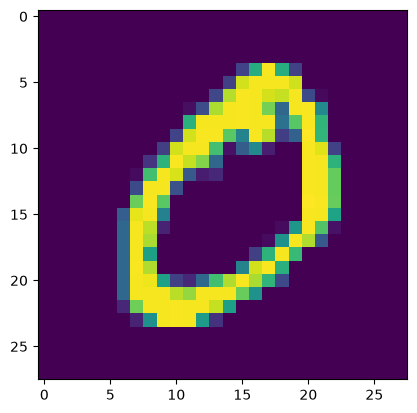

In [52]:
# Example of a training image
plt.imshow(x_tr[1]);

In [58]:
# sampling function corregida para Keras 3
def sampling(args):
    mu, log_var = args
    # Usamos tf.random.normal asegurando el batch_size y z_dim de forma dinámica
    batch_size_dim = tf.shape(mu)[0]
    eps = tf.random.normal(shape=(batch_size_dim, z_dim), mean=0., stddev=1.0)
    return mu + ops.exp(log_var) * eps

In [59]:
# Capa personalizada para calcular e inyectar la pérdida KL de forma nativa en Keras 3
class KLLossLayer(Layer):
    def call(self, inputs):
        mu, log_var = inputs
        kl = -0.5 * ops.sum(1 + log_var - ops.square(mu) - ops.exp(log_var), axis=-1)
        self.add_loss(ops.mean(kl))
        return mu

# Encoder - from 784->256->128->2
inputs_flat = Input(shape=(x_tr_flat.shape[1],))
x_flat = Dense(n_hidden, activation='relu')(inputs_flat) # first hidden layer
x_flat = Dense(n_hidden//2, activation='relu')(x_flat)  # second hidden layer

# hidden state
mu_flat = Dense(z_dim)(x_flat)
log_var_flat = Dense(z_dim)(x_flat)

# Aplicamos la capa que calcula la KL loss internamente y devuelve mu para el sampling
mu_kl_checked = KLLossLayer()([mu_flat, log_var_flat])

# Usamos mu_kl_checked (o mu_flat y log_var_flat) en la capa Lambda
z_flat = Lambda(sampling, output_shape=(z_dim,))([mu_flat, log_var_flat])

In [60]:
#Decoder - from 2->128->256->784
latent_inputs = Input(shape=(z_dim,))
z_decoder1 = Dense(n_hidden//2, activation='relu')
z_decoder2 = Dense(n_hidden, activation='relu')
y_decoder = Dense(x_tr_flat.shape[1], activation='sigmoid')
z_decoded = z_decoder1(latent_inputs)
z_decoded = z_decoder2(z_decoded)
y_decoded = y_decoder(z_decoded)
decoder_flat = Model(latent_inputs, y_decoded, name="decoder_conv")

outputs_flat = decoder_flat(z_flat)

In [62]:

def vae_loss_function(y_true, y_pred):
    # 1. Pérdida de reconstrucción
    rec_loss = losses.binary_crossentropy(y_true, y_pred) * x_tr_flat.shape[1]
    
    # 2. Divergencia KL (usando las variables globales mu_flat y log_var_flat de tu entorno)
    kl = -0.5 * ops.sum(1 + log_var_flat - ops.square(mu_flat) - ops.exp(log_var_flat), axis=-1)
    
    return rec_loss + kl

# Compilamos el modelo funcional estándar sin usar add_loss()
vae_flat = Model(inputs_flat, outputs_flat)
vae_flat.compile(optimizer='adam', loss=vae_loss_function)

In [63]:
# Build model
vae_flat = Model(inputs_flat, outputs_flat)

# Compilamos únicamente con la pérdida de reconstrucción (la KL ya va por dentro con add_loss)
vae_flat.compile(optimizer='adam', loss=losses.binary_crossentropy)

In [64]:
# train
vae_flat.fit(
    x=x_tr_flat,
    y=x_tr_flat,
    shuffle=True,
    epochs=n_epoch,
    batch_size=batch_size,
    validation_data=(x_te_flat, x_te_flat),
    verbose=1
)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.2430 - val_loss: 0.2098
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2024 - val_loss: 0.1969
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1928 - val_loss: 0.1895
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1870 - val_loss: 0.1856
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1834 - val_loss: 0.1827
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1810 - val_loss: 0.1816
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1791 - val_loss: 0.1796
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1775 - val_loss: 0.1782
Epoch 9/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1763 - val_loss: 0.1778
Epoch 10/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1749 - val_loss: 0.1762
Epoch 11/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1740 - val_loss: 0.1752
Epoch 12/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step

KeyboardInterrupt: 